In [1]:
import os
import geopandas as gpd

# folder containing the Torino files
folder = "src/main/resources/Torino"

buildings_path = os.path.join(folder, "Torino_buildings.gpkg")
punti_path = os.path.join(folder, "Torino_puntiLuce.gpkg")

# read; if the GeoPackage has multiple layers, specify layer="<layername>"
buildings = gpd.read_file(buildings_path)
punti = gpd.read_file(punti_path)

print("Buildings CRS:", buildings.crs)
print("Punti CRS:", punti.crs)
print("Buildings count:", len(buildings), "Punti count:", len(punti))

Buildings CRS: EPSG:3003
Punti CRS: EPSG:3003
Buildings count: 20701 Punti count: 99742


In [2]:
import numpy as np
import pandas as pd

# Ensure numeric columns are numeric and force invalid entries to NaN
punti["potenza_w_max"] = pd.to_numeric(punti["potenza_w_max"], errors="coerce")
punti["altezza_palo_m"] = pd.to_numeric(punti["altezza_palo_m"], errors="coerce")
punti["braccio_l_m_max"] = pd.to_numeric(punti["braccio_l_m_max"], errors="coerce")

# 1. Data Cleaning & Imputation

# Cap extreme wattage values at NaN for later imputation
punti.loc[punti["potenza_w_max"] > 500, "potenza_w_max"] = np.nan

# Impute potenza_w_max by technology median, then global median
potenza_median_by_tech = punti.groupby("tecnologia")["potenza_w_max"].transform("median")
global_potenza_median = punti["potenza_w_max"].median()
punti["potenza_w_max"] = punti["potenza_w_max"].fillna(potenza_median_by_tech)
punti["potenza_w_max"] = punti["potenza_w_max"].fillna(global_potenza_median)

# Impute altezza_palo_m by optics usage median, then default 9.0
altezza_median_by_optics = punti.groupby("uso_ottica")["altezza_palo_m"].transform("median")
punti["altezza_palo_m"] = punti["altezza_palo_m"].fillna(altezza_median_by_optics)
punti["altezza_palo_m"] = punti["altezza_palo_m"].fillna(9.0)

# Fill missing arm lengths with 0.0
punti["braccio_l_m_max"] = punti["braccio_l_m_max"].fillna(0.0)

# 2. Mapping Technology & Optics

luminous_efficacy_map = {
    "LED / probabile LED": 120,
    "scarica / HID-CDM-HQL": 90,
    "non determinata": 70,
}

utilization_factor_map = {
    "stradale": 0.6,
    "viali": 0.6,
    "sospeso": 0.4,
    "storico/decorativo; sospeso": 0.35,
    "storico/decorativo": 0.3,
    "non determinato": 0.4,
}

punti["luminous_efficacy"] = punti["tecnologia"].map(luminous_efficacy_map)
punti["utilization_factor"] = punti["uso_ottica"].map(utilization_factor_map)

# Provide sensible defaults for unmapped categories
punti["luminous_efficacy"] = punti["luminous_efficacy"].fillna(70)
punti["utilization_factor"] = punti["utilization_factor"].fillna(0.4)

# 3. Physics Calculations (Feature Engineering)

# total lumens from wattage and efficacy
punti["total_lumens"] = punti["potenza_w_max"] * punti["luminous_efficacy"]

# downward luminous intensity in candela
punti["downward_intensity_cd"] = (punti["total_lumens"] * punti["utilization_factor"]) / np.pi

# luminous radius based on inverse-square law and 5 Lux threshold
E_min = 5.0
I = punti["downward_intensity_cd"]
h = punti["altezza_palo_m"]

# r = sqrt( ((I * h) / E_min)^(2/3) - h^2 )
radius_term = np.power((I * h) / E_min, 2.0 / 3.0) - np.power(h, 2.0)
punti["luminous_radius_m"] = np.sqrt(np.clip(radius_term, a_min=0.0, a_max=None))

# Optional: if any values are still NaN due to invalid inputs, set them to 0
punti["luminous_radius_m"] = punti["luminous_radius_m"].fillna(0.0)

In [5]:
punti

,sede_tecnica,root_sede,via,tipo_da_codifica,tipo_supporto,tecnologia,uso_ottica,palo_codes,tipo_palo,altezza_palo_m,diametro_base_mm,app_codes,braccio_l_m_max,potenza_w_max,geometry,luminous_efficacy,utilization_factor,total_lumens,downward_intensity_cd,luminous_radius_m
0,CI-C-AB -001,CI-C-AB-001,AGNELLI Giovanni,singolo apparecchio secondo codifica,palo presente sulla stessa sede,LED / probabile LED,non determinato,10000485,,12.1,105.0,1074127,2.0,147.0,POINT (1393659.42 4988690.914),120,0.4,17640.0,2245.994557,12.756404
1,CI-C-AB -001A,CI-C-AB-001,AGNELLI Giovanni,punto luce con piu apparecchi / progressivo ap...,palo presente sulla stessa sede,LED / probabile LED,non determinato,1004418,rastremato,11.5,273.0,1074136,0.0,57.0,POINT (1393656.578 4988659.72),120,0.4,6840.0,870.895849,5.162558
2,CI-C-AB -001B,CI-C-AB-001,AGNELLI Giovanni,punto luce con piu apparecchi / progressivo ap...,solo apparecchio in distinta,LED / probabile LED,stradale,,,9.0,NaN,1020360,0.0,96.0,POINT (1393651.66 4988662.233),120,0.6,11520.0,2200.157933,13.012051
3,CI-C-AB -001C,CI-C-AB-001,AGNELLI Giovanni,centro strada / strada con tre-cinque file sec...,solo apparecchio in distinta,LED / probabile LED,sospeso,,,11.0,NaN,1075777,0.0,132.0,POINT (1393649.129 4988692.475),120,0.4,15840.0,2016.811439,12.207274
4,CI-C-AB -001L,CI-C-AB-001,AGNELLI Giovanni,laterale / strada con tre o piu file secondo c...,solo apparecchio in distinta,LED / probabile LED,stradale,,,9.0,NaN,1020374,0.0,126.0,POINT (1393666.849 4988684.916),120,0.6,15120.0,2887.707287,14.800886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99737,CI-C-ZX -102,CI-C-ZX-102,Sottopasso STATUTO,singolo apparecchio secondo codifica,solo apparecchio in distinta,LED / probabile LED,non determinato,,,5.6,NaN,1044418,0.0,39.6,POINT (1395302.741 4992483.273),120,0.4,4752.0,605.043432,6.766837
99738,CI-C-ZX -103,CI-C-ZX-103,Sottopasso STATUTO,singolo apparecchio secondo codifica,solo apparecchio in distinta,LED / probabile LED,non determinato,,,5.6,NaN,1044417,0.0,448.6,POINT (1395285.86 4992485.316),120,0.4,53832.0,6854.103117,18.915229
99739,CI-C-ZX -105,CI-C-ZX-105,Sottopasso STATUTO,singolo apparecchio secondo codifica,solo apparecchio in distinta,LED / probabile LED,non determinato,,,5.6,NaN,1044417,0.0,448.6,POINT (1395286.727 4992487.25),120,0.4,53832.0,6854.103117,18.915229
99740,CI-C-ZX -107,CI-C-ZX-107,Sottopasso STATUTO,singolo apparecchio secondo codifica,solo apparecchio in distinta,LED / probabile LED,non determinato,,,5.6,NaN,1044417,0.0,448.6,POINT (1395287.661 4992489.233),120,0.4,53832.0,6854.103117,18.915229


In [6]:
import geopandas as gpd
from shapely.ops import unary_union
from pyproj import CRS

def ensure_metric(gdf):
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS. Set it before reprojecting.")
    if CRS(gdf.crs).is_geographic:
        centroid = gdf.to_crs("EPSG:4326").unary_union.centroid
        zone = int((centroid.x + 180) / 6) + 1
        epsg = 32600 + zone if centroid.y >= 0 else 32700 + zone
        return gdf.to_crs(epsg)
    return gdf.to_crs(gdf.crs)

punti_metric = ensure_metric(punti)
buildings_metric = buildings.to_crs(punti_metric.crs)

n_test_punti = min(99742, len(punti_metric))
punti_test = punti_metric.iloc[:n_test_punti].copy()

# Use the already-calculated luminous_radius_m
punti_buffers = punti_test.copy()
punti_buffers["geometry"] = punti_test.geometry.buffer(punti_test["luminous_radius_m"])

max_radius = punti_buffers["luminous_radius_m"].max()
minx, miny, maxx, maxy = punti_buffers.total_bounds
expanded_bounds = (minx - max_radius, miny - max_radius,
                   maxx + max_radius, maxy + max_radius)

candidate_idx = list(buildings_metric.sindex.intersection(expanded_bounds))
candidates = buildings_metric.iloc[candidate_idx].copy()

filtered = gpd.sjoin(
    candidates,
    punti_buffers[["geometry"]],
    how="inner",
    predicate="intersects",
)

filtered_buildings = candidates.loc[filtered.index.unique()].copy()

lit_union = unary_union(punti_buffers.geometry)

if len(filtered_buildings):
    building_union = unary_union(filtered_buildings.geometry)
    lit_area = lit_union.difference(building_union)
else:
    lit_area = lit_union

lit_areas_gdf = gpd.GeoDataFrame(
    {"source": ["lit_area"]},
    geometry=[lit_area],
    crs=punti_metric.crs,
)

C:\Users\sgabalog\AppData\Local\Temp\ipykernel_3720\2970804699.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_3720\2970804699.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


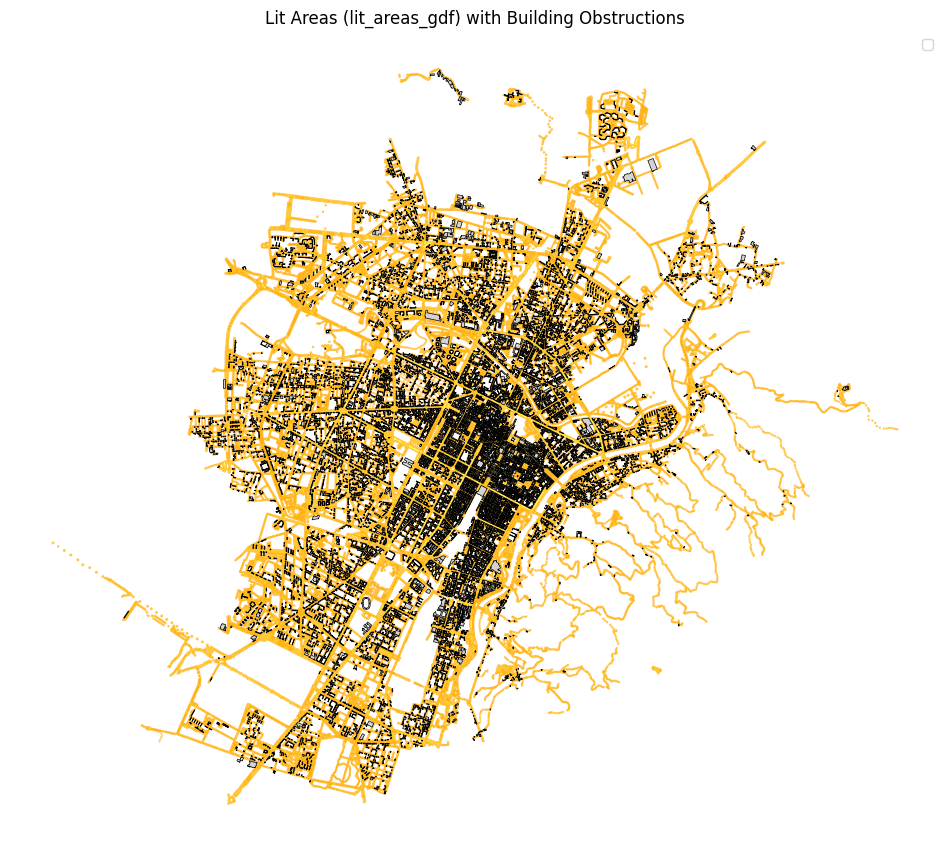

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

lit_areas_gdf.plot(ax=ax, color="yellow", alpha=0.6, edgecolor="orange", linewidth=1, label="Lit Areas")
filtered_buildings.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5, label="Blocking Buildings")
#punti_test.plot(ax=ax, color="blue", markersize=20, label="Lamp Points")

ax.set_title("Lit Areas (lit_areas_gdf) with Building Obstructions")
ax.set_axis_off()
ax.legend(loc="upper right")
plt.show()


In [8]:
import os
from pathlib import Path

input_path = punti_path
folder = os.path.dirname(input_path)
ext = Path(input_path).suffix.lower()

if ext == ".gpkg":
    driver = "GPKG"
elif ext == ".shp":
    driver = "ESRI Shapefile"
else:
    driver = None

punti_out = os.path.join(folder, "Torino_puntiLuce_updated" + ext)
lit_out = os.path.join(folder, "Torino_lit_areas" + ext)

punti.to_file(punti_out, driver=driver)
lit_areas_gdf.to_file(lit_out, driver=driver)

print("Saved punti to:", punti_out)
print("Saved lit areas to:", lit_out)

Saved punti to: src/main/resources/Torino\Torino_puntiLuce_updated.gpkg
Saved lit areas to: src/main/resources/Torino\Torino_lit_areas.gpkg
